In [15]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# Parámetros físicos
g = 9.81
v0 = 20.0
theta = np.deg2rad(45)
v0x = v0 * np.cos(theta)
v0y = v0 * np.sin(theta)

# Tiempo de vuelo y generación de datos
t_vuelo = 2 * v0y / g
t_datos = np.linspace(0, t_vuelo, 15).reshape(-1, 1)

# Ecuaciones de movimiento (sin ruido)
x_real = v0x * t_datos
y_real = v0y * t_datos - 0.5 * g * t_datos**2

# Añadir ruido gaussiano a las observaciones
noise_std = 0.9
rng = np.random.default_rng(42)
x_noisy = x_real + rng.normal(0, noise_std, size=x_real.shape)
y_noisy = y_real + rng.normal(0, noise_std, size=y_real.shape)

# Convertir a tensores para PyTorch
t_train = torch.tensor(t_datos, dtype=torch.float32, requires_grad=True)
pos_train = torch.tensor(np.hstack((x_noisy, y_noisy)), dtype=torch.float32)

# Puntos de colocación (donde evaluaremos la física de la EDO)
t_physics = torch.linspace(0, t_vuelo, 50).view(-1, 1).requires_grad_(True)

In [17]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)  # Salida: [x, y]
        )

    def forward(self, t):
        return self.net(t)


class RedNeuronalEstandar(nn.Module):
    def __init__(self):
        super(RedNeuronalEstandar, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)  # Salida: [x, y]
        )

    def forward(self, t):
        return self.net(t)


model = PINN()
model_nn = RedNeuronalEstandar()

In [18]:
def compute_physics_loss(t):
    pred = model(t)
    x = pred[:, 0:1]
    y = pred[:, 1:2]

    # Primera derivada (Velocidad)
    dx_dt = torch.autograd.grad(x, t, torch.ones_like(x), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y, t, torch.ones_like(y), create_graph=True)[0]

    # Segunda derivada (Aceleración)
    d2x_dt2 = torch.autograd.grad(dx_dt, t, torch.ones_like(dx_dt), create_graph=True)[0]
    d2y_dt2 = torch.autograd.grad(dy_dt, t, torch.ones_like(dy_dt), create_graph=True)[0]

    # Residuales de las ecuaciones diferenciales
    loss_x = torch.mean(d2x_dt2**2)
    loss_y = torch.mean((d2y_dt2 + g)**2)

    return loss_x + loss_y

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer_nn = torch.optim.Adam(model_nn.parameters(), lr=0.001)

loss_history_pinn = []
loss_history_nn = []

In [20]:
epochs = 4000
for epoch in range(epochs):
    # Entrenamiento PINN
    optimizer.zero_grad()
    pred_data = model(t_train)
    loss_data = torch.mean((pred_data - pos_train)**2)
    loss_physics = compute_physics_loss(t_physics)
    total_loss_pinn = loss_data + loss_physics
    total_loss_pinn.backward()
    optimizer.step()

    # Entrenamiento red neuronal estándar (solo datos)
    optimizer_nn.zero_grad()
    pred_data_nn = model_nn(t_train)
    total_loss_nn = torch.mean((pred_data_nn - pos_train)**2)
    total_loss_nn.backward()
    optimizer_nn.step()

    # Guardar historial
    loss_history_pinn.append(total_loss_pinn.item())
    loss_history_nn.append(total_loss_nn.item())

    if epoch % 1000 == 0:
        print(
            f"Época {epoch} | PINN Loss: {total_loss_pinn.item():.6f} | NN Loss: {total_loss_nn.item():.6f}"
        )

Época 0 | PINN Loss: 414.283386 | NN Loss: 316.533600
Época 1000 | PINN Loss: 16.299793 | NN Loss: 2.845047
Época 2000 | PINN Loss: 0.420555 | NN Loss: 0.230679
Época 3000 | PINN Loss: 0.415648 | NN Loss: 0.084039


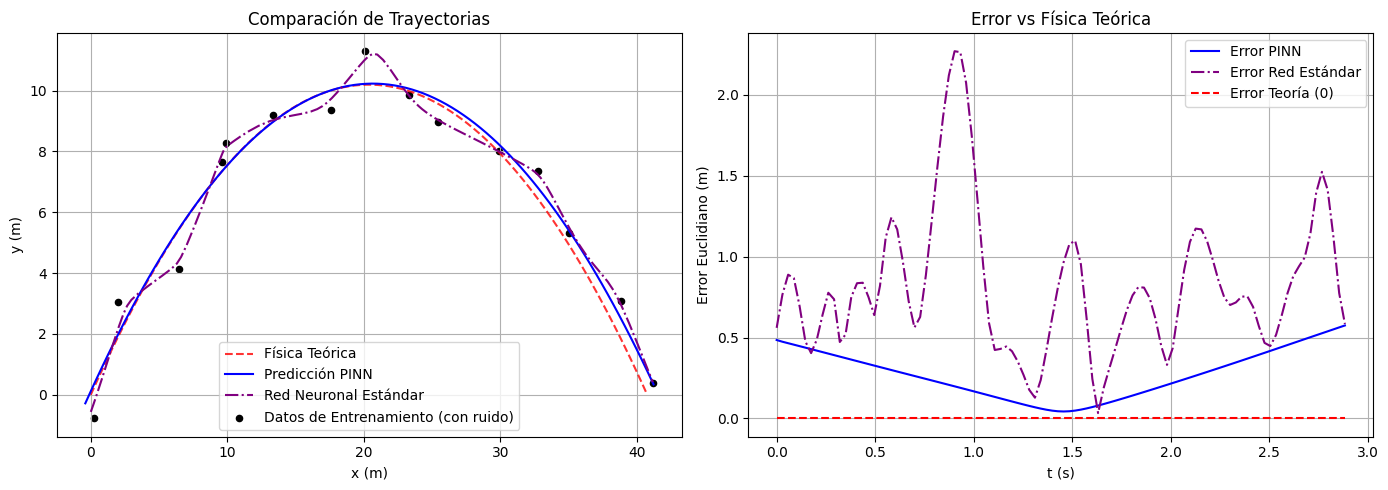

In [22]:
# Preparar datos para graficar
t_test = torch.linspace(0, t_vuelo, 100).view(-1, 1)
with torch.no_grad():
    pred_test_pinn = model(t_test).numpy()
    pred_test_nn = model_nn(t_test).numpy()

x_p, y_p = pred_test_pinn[:, 0], pred_test_pinn[:, 1]
x_n, y_n = pred_test_nn[:, 0], pred_test_nn[:, 1]
t_np = t_test.numpy()
x_r = v0x * t_np
y_r = v0y * t_np - 0.5 * g * t_np**2

# Error euclidiano respecto a la física teórica
error_pinn = np.sqrt((x_p - x_r.squeeze())**2 + (y_p - y_r.squeeze())**2)
error_nn = np.sqrt((x_n - x_r.squeeze())**2 + (y_n - y_r.squeeze())**2)
error_teoria = np.zeros_like(t_np.squeeze())

plt.figure(figsize=(14, 5))

# Gráfica 1: Trayectorias
plt.subplot(1, 2, 1)
plt.plot(x_r, y_r, 'r--', label='Física Teórica', alpha=0.8)
plt.plot(x_p, y_p, 'b-', label='Predicción PINN')
plt.plot(x_n, y_n, color='purple', linestyle='-.', label='Red Neuronal Estándar')
plt.scatter(x_noisy, y_noisy, color='black', s=20, label='Datos de Entrenamiento (con ruido)')
plt.title('Comparación de Trayectorias')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.legend()
plt.grid(True)

# Gráfica 2: Comparación de error contra la física teórica
plt.subplot(1, 2, 2)
plt.plot(t_np.squeeze(), error_pinn, 'b-', label='Error PINN')
plt.plot(t_np.squeeze(), error_nn, color='purple', linestyle='-.', label='Error Red Estándar')
plt.plot(t_np.squeeze(), error_teoria, 'r--', label='Error Teoría (0)')
plt.title('Error vs Física Teórica')
plt.xlabel('t (s)')
plt.ylabel('Error Euclidiano (m)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()